In [1]:
import tensorflow as tf
import numpy as np
import scipy.io
from scipy.interpolate import griddata
from pyDOE import lhs
import time
from Impact_dampers_PINN_5dofs import PIPNNs
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '0'  # CPU:-1; GPU0: 1; GPU1: 0;
#import tensorflow.compat.v1 as tf
#tf.disable_v2_behavior()

In [2]:
# generates same random numbers each time
np.random.seed(1234)
tf.compat.v1.set_random_seed(1234)

print("TensorFlow version: {}".format(tf.__version__))

TensorFlow version: 1.15.0


In [3]:
import matplotlib.pyplot as plt

In [4]:
mx1 = 1
my1 = 0
k1 = 1
mx2 = 1
my2 = 0
k2 = 1
mx3 = 1
my3 = 0
k3 = 1
mx4 = 1
my4 = 0.3
k4 = 1
D = 1
r = 1
f = 1
n_dof = 5

# Create the matrix A
A = np.array([[mx4, my4],
              [1, -1]])

# Create the matrix B
B = np.array([[mx4, my4],
              [-r, r]])

A_inv = np.linalg.inv(A)
A_inv_B= np.dot(A_inv, B)

M_primary = 1
K_primary = 1

In [5]:
M_total = np.array([[mx1, 0, 0, 0, 0],
                    [0, mx2, 0, 0, 0],
                    [0, 0, mx3, 0, 0],
                    [0, 0, 0, mx4, 0],
                    [0, 0, 0, 0, M_primary]])
K_total = np.array([[k1+k2, -k2, 0, 0, 0],
                    [-k2, k2+k3, -k3, 0, 0],
                    [0, -k3, k3+k4, -k4, 0],
                    [0, 0, -k4, k4+K_primary, -K_primary],
                    [0, 0, 0, -K_primary, K_primary]])
C_total = np.zeros([5,5])

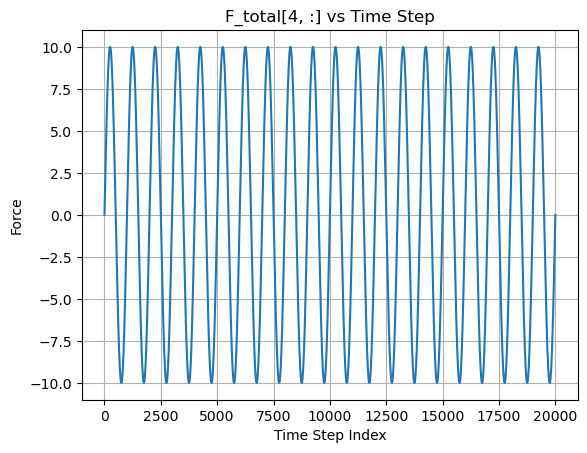

In [6]:
time_step=0.001
T=20
num=20001
t_or = np.arange(0, 20.001, 0.001)
t_or = t_or.reshape(-1, 1)

phi1 = np.array([[10]])
phi2 = np.array([[2]])

F_total = np.zeros((n_dof, num))
F_total[n_dof-1, :] = phi1*np.sin(phi2*np.pi*t_or).flatten() 

plt.plot(F_total[n_dof-1, :])
plt.title('F_total[4, :] vs Time Step')
plt.xlabel('Time Step Index')
plt.ylabel('Force')
plt.grid(True)
plt.show()

In [7]:
x01 = np.array([[0]])
xt01 = np.array([[0]])
x02 = np.array([[0]])
xt02 = np.array([[0]])
x03 = np.array([[0]])
xt03 = np.array([[0]])
x04 = np.array([[0]])
xt04 = np.array([[0]])
y04 = np.array([[0]])
yt04 = np.array([[0]])

x0_primary = np.array([[0]])
xt0_primary = np.array([[0]])

x0_total = np.hstack([x01, x02, x03, x04, x0_primary])

xt0_total = np.hstack([xt01, xt02, xt03, xt04, xt0_primary])

t0=t_or[0,None]

In [8]:
from scipy.linalg import eigh, solve
def newmark_beta(M, C, K, P, dt, n_steps, n_dof, u0=None, ut0=None):
    gamma, beta = 0.5, 0.25

    # Initialize arrays
    u = np.zeros((n_dof, n_steps))
    ut = np.zeros_like(u)
    utt = np.zeros_like(u)
    
    # Set initial conditions (if provided)
    if u0 is not None:
        u[:, 0] = u0
    if ut0 is not None:
        ut[:, 0] = ut0
    
    # Compute initial acceleration
    utt[:, 0] = solve(M, P[:, 0] - C @ ut[:, 0] - K @ u[:, 0])
    
    # Precompute and factorize the effective stiffness matrix (if constant)
    eff_stiffness = M + gamma * dt * C + beta * dt**2 * K
    # (Optional: Use sparse LU decomposition here for large systems)
    
    # Time stepping
    for t in range(1, n_steps):
        # Prediction
        u_pred = u[:, t-1] + dt * ut[:, t-1] + (0.5 - beta) * dt**2 * utt[:, t-1]
        ut_pred = ut[:, t-1] + (1 - gamma) * dt * utt[:, t-1]
        
        # Solve for new acceleration
        utt[:, t] = solve(
            eff_stiffness,  # Reuse precomputed matrix
            P[:, t] - C @ ut_pred - K @ u_pred
        )
        
        # Correction
        ut[:, t] = ut_pred + gamma * dt * utt[:, t]
        u[:, t] = u_pred + beta * dt**2 * utt[:, t]
    
    return u, ut, utt


In [9]:
u_NM, ut_NM, utt_NM = newmark_beta(M_total, C_total, K_total, F_total, time_step, num, n_dof)

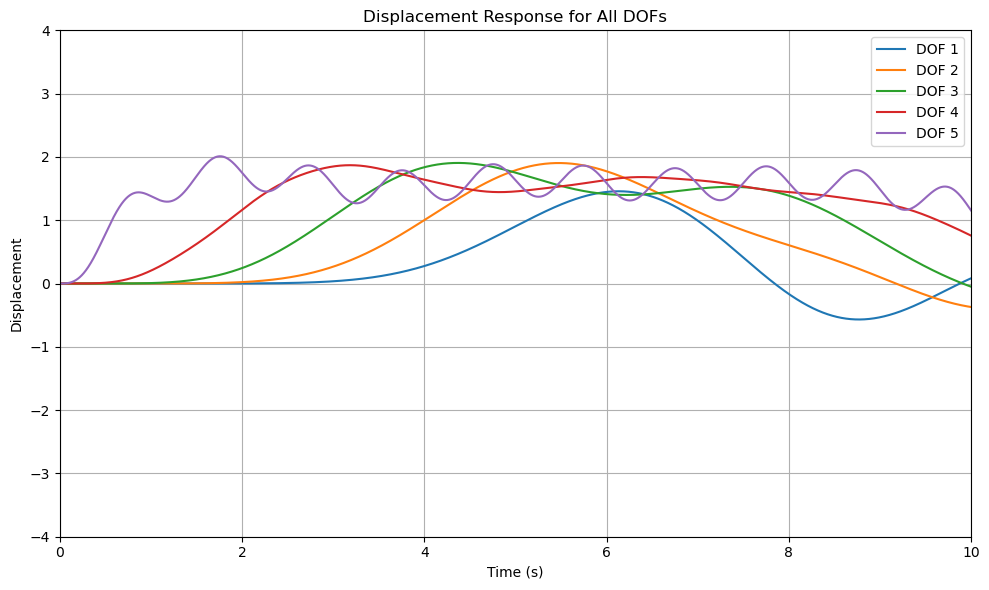

In [10]:
plt.figure(figsize=(10, 6))
for i in range(n_dof):
    plt.plot(t_or, u_NM[i, :], label=f'DOF {i+1}')

plt.title('Displacement Response for All DOFs')
plt.xlabel('Time (s)')
plt.ylabel('Displacement')
plt.legend()
plt.xlim(0, 10)
plt.ylim(-4, 4)
plt.grid(True)
plt.tight_layout()
plt.show()

In [11]:
# Domain bounds
lb = np.array([0])
ub = np.array([1])

In [12]:
# Hyper-parameters
optimizer_LB_value = True
hyp_ini_weight_loss = np.array([1, 1, 1])

In [13]:
num = 64
layers = [1, num, n_dof]

In [14]:
impact_times = []
system_responses = []
n_impact = 4
num_vector = [1000, 1000, 1000, 1000, 1000, 1000, 1000]
T_vector = np.array([4, 4, 5, 2, 4, 4, 4])
hyp_ini_para_vector = np.array([2, 2, 3, 1, 2, 2, 2])

In [15]:
# Initialize lists to store responses for each impact
time_list = []
time_log_list = []
x_list = []
xt_list = []
xtt_list = []
y_list = []
yt_list = []
ytt_list = []
phi = np.array([[0]])

In [16]:
for i in range(n_impact):
    print(f"\nSimulating Impact {i+1}...")

    T= T_vector[i]
    hyp_ini_para = [hyp_ini_para_vector[i]]
    num =1000
    nIter= num_vector[i]

    # Reset time domain for the next phase
    t0 = np.array([[0.0]])  # Reset initial time
    t = np.linspace(0, T, num).reshape(-1, 1)  # Reset time domain

    # Initialize the model
    model = PIPNNs(lb, ub, t0, t, x0_total, xt0_total, y04, yt04, M_total, K_total, D, n_dof, phi, phi1, phi2,
              layers, hyp_ini_weight_loss, hyp_ini_para, optimizer_LB_value)
    
    # Train the model
    model.train(nIter=nIter, optimizer_LB=True)

    # Get impact time and system response at impact
    lambda_1_value = model.sess.run(model.lambda_1)
    t_impact=np.reshape(lambda_1_value, [1, 1])
    lambda_1_log = model.lambda_1_log
    
    x1_pred, xt1_pred, xtt1_pred= model.predict(t_impact)
    y1_pred = yt04*t_impact+y04
    yt1_pred = yt04
    
    impact_times.append(lambda_1_value)

    # Simulate the system from initial time to impact time
    t_sim = np.linspace(0, t_impact[0], num+1).reshape(-1, 1)  # Time steps from 0 to t_impact
    
    x_sim, xt_sim, xtt_sim = model.predict(t_sim)
    y_sim = yt04*t_sim+y04
    yt_sim = yt04*np.ones((num+1, 1))
    ytt_sim = np.zeros((num+1, 1))

    time_list.append(t_sim + sum(impact_times[:i]))
    time_log_list.append(lambda_1_log)
    x_list.append(x_sim)
    xt_list.append(xt_sim)
    xtt_list.append(xtt_sim)
    y_list.append(y_sim)
    yt_list.append(yt_sim)
    ytt_list.append(ytt_sim)

    # Update initial conditions for the next impact
    V0 = np.vstack((xt1_pred[:,3:4], yt04))
    V1 = np.dot(A_inv_B, V0)
    
    x0_total = x1_pred
    xt0_total = xt1_pred 
    xt0_total[:,3:4] = V1[0,None]
    y04 = y1_pred
    yt04 = V1[1,None]
    phi=sum(impact_times[:i+1])
    phi = np.array([[phi]])


Simulating Impact 1...

The TensorFlow contrib module will not be included in TensorFlow 2.0.
For more information, please see:
  * https://github.com/tensorflow/community/blob/master/rfcs/20180907-contrib-sunset.md
  * https://github.com/tensorflow/addons
  * https://github.com/tensorflow/io (for I/O related ops)
If you depend on functionality not listed there, please file an issue.




Device mapping:


It: 0, Loss: 1.147e+01, Loss_icx: 1.571e-01,  Loss_fx: 1.047e+01, Loss_f: 8.467e-01, Lambda_1: 2.001, Time: 2.87
It: 10, Loss: 1.078e+01, Loss_icx: 8.222e-02,  Loss_fx: 1.025e+01, Loss_f: 4.455e-01, Lambda_1: 2.011, Time: 0.99
It: 20, Loss: 1.039e+01, Loss_icx: 6.247e-02,  Loss_fx: 1.011e+01, Loss_f: 2.155e-01, Lambda_1: 2.022, Time: 0.93
It: 30, Loss: 1.018e+01, Loss_icx: 6.858e-02,  Loss_fx: 9.982e+00, Loss_f: 1.312e-01, Lambda_1: 2.032, Time: 0.82
It: 40, Loss: 1.009e+01, Loss_icx: 9.475e-02,  Loss_fx: 9.944e+00, Loss_f: 5.587e-02, Lambda_1: 2.041, Time: 0.83
It: 50, Loss: 1.007e+

It: 580, Loss: 8.376e+00, Loss_icx: 2.886e-02,  Loss_fx: 8.345e+00, Loss_f: 2.298e-03, Lambda_1: 2.373, Time: 0.48
It: 590, Loss: 8.303e+00, Loss_icx: 2.491e-02,  Loss_fx: 8.276e+00, Loss_f: 1.896e-03, Lambda_1: 2.377, Time: 0.45
It: 600, Loss: 8.234e+00, Loss_icx: 2.126e-02,  Loss_fx: 8.211e+00, Loss_f: 1.529e-03, Lambda_1: 2.381, Time: 0.57
It: 610, Loss: 8.169e+00, Loss_icx: 1.798e-02,  Loss_fx: 8.149e+00, Loss_f: 1.202e-03, Lambda_1: 2.385, Time: 0.38
It: 620, Loss: 8.108e+00, Loss_icx: 1.511e-02,  Loss_fx: 8.092e+00, Loss_f: 9.192e-04, Lambda_1: 2.388, Time: 0.35
It: 630, Loss: 8.051e+00, Loss_icx: 1.269e-02,  Loss_fx: 8.038e+00, Loss_f: 6.814e-04, Lambda_1: 2.392, Time: 0.37
It: 640, Loss: 8.000e+00, Loss_icx: 1.072e-02,  Loss_fx: 7.989e+00, Loss_f: 4.875e-04, Lambda_1: 2.394, Time: 0.31
It: 650, Loss: 7.953e+00, Loss_icx: 9.180e-03,  Loss_fx: 7.944e+00, Loss_f: 3.345e-04, Lambda_1: 2.397, Time: 0.34
It: 660, Loss: 7.911e+00, Loss_icx: 8.043e-03,  Loss_fx: 7.903e+00, Loss_f: 2.18

Loss: 5.142900e+00, Loss_icx: 4.32227e-02, Loss_fx: 5.09869e+00, Loss_f: 9.86999e-04, l1: 2.30837
Loss: 5.114922e+00, Loss_icx: 4.06607e-02, Loss_fx: 5.07401e+00, Loss_f: 2.48109e-04, l1: 2.31664
Loss: 5.096121e+00, Loss_icx: 4.46350e-02, Loss_fx: 5.05136e+00, Loss_f: 1.24969e-04, l1: 2.32253
Loss: 5.061576e+00, Loss_icx: 5.13777e-02, Loss_fx: 5.00954e+00, Loss_f: 6.59441e-04, l1: 2.33215
Loss: 5.092609e+00, Loss_icx: 5.46181e-02, Loss_fx: 5.03753e+00, Loss_f: 4.57979e-04, l1: 2.33822
Loss: 5.047550e+00, Loss_icx: 5.20845e-02, Loss_fx: 4.99485e+00, Loss_f: 6.16652e-04, l1: 2.33441
Loss: 5.013675e+00, Loss_icx: 4.30279e-02, Loss_fx: 4.96990e+00, Loss_f: 7.51146e-04, l1: 2.32502
Loss: 4.979332e+00, Loss_icx: 3.79829e-02, Loss_fx: 4.94039e+00, Loss_f: 9.56609e-04, l1: 2.32375
Loss: 4.950689e+00, Loss_icx: 3.40867e-02, Loss_fx: 4.91527e+00, Loss_f: 1.33342e-03, l1: 2.32849
Loss: 4.917442e+00, Loss_icx: 3.13552e-02, Loss_fx: 4.88449e+00, Loss_f: 1.59717e-03, l1: 2.33032
Loss: 4.921725e+00, 

Loss: 2.679887e+00, Loss_icx: 1.79517e-02, Loss_fx: 2.66191e+00, Loss_f: 2.44876e-05, l1: 2.10676
Loss: 2.653514e+00, Loss_icx: 2.72180e-02, Loss_fx: 2.62618e+00, Loss_f: 1.15889e-04, l1: 2.10549
Loss: 2.630598e+00, Loss_icx: 3.12181e-02, Loss_fx: 2.59906e+00, Loss_f: 3.16767e-04, l1: 2.11259
Loss: 2.617688e+00, Loss_icx: 2.63819e-02, Loss_fx: 2.59128e+00, Loss_f: 2.28808e-05, l1: 2.10029
Loss: 2.609389e+00, Loss_icx: 1.61480e-02, Loss_fx: 2.59188e+00, Loss_f: 1.36454e-03, l1: 2.09032
Loss: 2.606140e+00, Loss_icx: 1.66670e-02, Loss_fx: 2.58899e+00, Loss_f: 4.79124e-04, l1: 2.06920
Loss: 2.598313e+00, Loss_icx: 1.53589e-02, Loss_fx: 2.58205e+00, Loss_f: 9.03750e-04, l1: 2.08073
Loss: 2.589562e+00, Loss_icx: 1.63467e-02, Loss_fx: 2.57319e+00, Loss_f: 2.33036e-05, l1: 2.08007
Loss: 2.548682e+00, Loss_icx: 1.38295e-02, Loss_fx: 2.53459e+00, Loss_f: 2.67269e-04, l1: 2.08192
Loss: 2.500275e+00, Loss_icx: 9.91697e-03, Loss_fx: 2.48981e+00, Loss_f: 5.43326e-04, l1: 2.09370
Loss: 2.520574e+00, 

Loss: 5.888300e-01, Loss_icx: 1.47264e-02, Loss_fx: 5.73986e-01, Loss_f: 1.17559e-04, l1: 2.38538
Loss: 5.859757e-01, Loss_icx: 1.62371e-02, Loss_fx: 5.69613e-01, Loss_f: 1.25727e-04, l1: 2.37767
Loss: 5.806404e-01, Loss_icx: 2.18163e-02, Loss_fx: 5.58794e-01, Loss_f: 3.01199e-05, l1: 2.36204
Loss: 5.735320e-01, Loss_icx: 2.31277e-02, Loss_fx: 5.50374e-01, Loss_f: 3.02666e-05, l1: 2.34357
Loss: 5.636905e-01, Loss_icx: 2.42388e-02, Loss_fx: 5.39444e-01, Loss_f: 7.68714e-06, l1: 2.32027
Loss: 5.571159e-01, Loss_icx: 2.02413e-02, Loss_fx: 5.36778e-01, Loss_f: 9.67836e-05, l1: 2.30594
Loss: 5.533276e-01, Loss_icx: 1.86327e-02, Loss_fx: 5.34352e-01, Loss_f: 3.42668e-04, l1: 2.30746
Loss: 5.512357e-01, Loss_icx: 1.78454e-02, Loss_fx: 5.32804e-01, Loss_f: 5.86273e-04, l1: 2.30274
Loss: 5.480970e-01, Loss_icx: 1.72809e-02, Loss_fx: 5.30358e-01, Loss_f: 4.58122e-04, l1: 2.29926
Loss: 5.399175e-01, Loss_icx: 1.53970e-02, Loss_fx: 5.24145e-01, Loss_f: 3.75292e-04, l1: 2.27796
Loss: 5.344734e-01, 

...

Loss: 4.865023e-06, Loss_icx: 6.96291e-10, Loss_fx: 4.86432e-06, Loss_f: 1.03597e-11, l1: 7.75029
Loss: 4.864633e-06, Loss_icx: 8.77084e-10, Loss_fx: 4.86373e-06, Loss_f: 2.27374e-11, l1: 7.75048
Loss: 4.862566e-06, Loss_icx: 8.41429e-10, Loss_fx: 4.86169e-06, Loss_f: 3.00702e-11, l1: 7.75054
Loss: 4.861299e-06, Loss_icx: 1.19909e-09, Loss_fx: 4.86009e-06, Loss_f: 8.88178e-12, l1: 7.75057
Loss: 4.860066e-06, Loss_icx: 1.58492e-09, Loss_fx: 4.85848e-06, Loss_f: 6.96332e-13, l1: 7.75045
Loss: 4.858215e-06, Loss_icx: 2.09349e-09, Loss_fx: 4.85612e-06, Loss_f: 5.13012e-12, l1: 7.75036
Loss: 4.856829e-06, Loss_icx: 2.66387e-09, Loss_fx: 4.85417e-06, Loss_f: 2.27374e-13, l1: 7.75025
Loss: 4.855714e-06, Loss_icx: 2.38919e-09, Loss_fx: 4.85331e-06, Loss_f: 1.03597e-11, l1: 7.75024
Loss: 4.854242e-06, Loss_icx: 2.19286e-09, Loss_fx: 4.85204e-06, Loss_f: 5.13012e-12, l1: 7.75021
Loss: 4.852736e-06, Loss_icx: 1.79783e-09, Loss_fx: 4.85093e-06, Loss_f: 8.18545e-12, l1: 7.75014
Loss: 4.849571e-06, 

Loss: 4.630860e-06, Loss_icx: 1.40689e-09, Loss_fx: 4.62945e-06, Loss_f: 9.09495e-13, l1: 7.74454
Loss: 4.628902e-06, Loss_icx: 1.34828e-09, Loss_fx: 4.62745e-06, Loss_f: 1.00272e-10, l1: 7.74438
Loss: 4.627145e-06, Loss_icx: 1.35153e-09, Loss_fx: 4.62578e-06, Loss_f: 1.27898e-11, l1: 7.74438
Loss: 4.625861e-06, Loss_icx: 1.32687e-09, Loss_fx: 4.62453e-06, Loss_f: 4.60432e-12, l1: 7.74425
Loss: 4.622575e-06, Loss_icx: 1.63479e-09, Loss_fx: 4.62087e-06, Loss_f: 7.36691e-11, l1: 7.74409
Loss: 4.619587e-06, Loss_icx: 1.81193e-09, Loss_fx: 4.61776e-06, Loss_f: 1.36566e-11, l1: 7.74387
Loss: 4.617033e-06, Loss_icx: 2.09109e-09, Loss_fx: 4.61492e-06, Loss_f: 1.84173e-11, l1: 7.74374
Loss: 4.650307e-06, Loss_icx: 5.49328e-09, Loss_fx: 4.64146e-06, Loss_f: 3.35655e-09, l1: 7.74375
Loss: 4.615819e-06, Loss_icx: 2.19769e-09, Loss_fx: 4.61360e-06, Loss_f: 1.84173e-11, l1: 7.74374
Loss: 4.613237e-06, Loss_icx: 2.59784e-09, Loss_fx: 4.61064e-06, Loss_f: 1.15108e-12, l1: 7.74362
Loss: 4.608210e-06, 

Loss: 4.215293e-06, Loss_icx: 1.96955e-09, Loss_fx: 4.21332e-06, Loss_f: 4.10694e-12, l1: 7.73561
Loss: 4.214044e-06, Loss_icx: 1.67335e-09, Loss_fx: 4.21237e-06, Loss_f: 1.71951e-12, l1: 7.73555
Loss: 4.208218e-06, Loss_icx: 1.21536e-09, Loss_fx: 4.20700e-06, Loss_f: 4.60432e-12, l1: 7.73535
Loss: 4.201051e-06, Loss_icx: 1.63938e-09, Loss_fx: 4.19939e-06, Loss_f: 2.16147e-11, l1: 7.73523
Loss: 4.212181e-06, Loss_icx: 4.44648e-09, Loss_fx: 4.20571e-06, Loss_f: 2.01977e-09, l1: 7.73504
Loss: 4.198299e-06, Loss_icx: 1.95622e-09, Loss_fx: 4.19623e-06, Loss_f: 1.15108e-10, l1: 7.73517
Loss: 4.192553e-06, Loss_icx: 2.58304e-09, Loss_fx: 4.18997e-06, Loss_f: 2.78533e-12, l1: 7.73519
Loss: 4.188062e-06, Loss_icx: 2.75980e-09, Loss_fx: 4.18530e-06, Loss_f: 1.42109e-14, l1: 7.73521
Loss: 4.185462e-06, Loss_icx: 2.03307e-09, Loss_fx: 4.18338e-06, Loss_f: 5.11591e-11, l1: 7.73517
Loss: 4.182153e-06, Loss_icx: 2.77774e-09, Loss_fx: 4.17907e-06, Loss_f: 3.02919e-10, l1: 7.73503
Loss: 4.178287e-06, 

Loss: 3.980100e-06, Loss_icx: 2.54840e-09, Loss_fx: 3.97706e-06, Loss_f: 4.91639e-10, l1: 7.72997
Loss: 3.977173e-06, Loss_icx: 3.66962e-09, Loss_fx: 3.97349e-06, Loss_f: 1.45519e-11, l1: 7.73000
Loss: 3.976368e-06, Loss_icx: 3.01263e-09, Loss_fx: 3.97335e-06, Loss_f: 2.40163e-12, l1: 7.72997
Loss: 3.975494e-06, Loss_icx: 1.83055e-09, Loss_fx: 3.97338e-06, Loss_f: 2.82526e-10, l1: 7.73000
Loss: 3.974245e-06, Loss_icx: 2.07615e-09, Loss_fx: 3.97201e-06, Loss_f: 1.56675e-10, l1: 7.72994
Loss: 3.972094e-06, Loss_icx: 2.07383e-09, Loss_fx: 3.96996e-06, Loss_f: 5.64029e-11, l1: 7.72991
Loss: 3.969741e-06, Loss_icx: 1.95914e-09, Loss_fx: 3.96778e-06, Loss_f: 3.63798e-12, l1: 7.72988
Loss: 3.968421e-06, Loss_icx: 1.69970e-09, Loss_fx: 3.96672e-06, Loss_f: 1.42109e-12, l1: 7.72989
Loss: 3.966309e-06, Loss_icx: 1.47172e-09, Loss_fx: 3.96483e-06, Loss_f: 5.13012e-12, l1: 7.72985
Loss: 3.971204e-06, Loss_icx: 3.51672e-09, Loss_fx: 3.96751e-06, Loss_f: 1.78261e-10, l1: 7.73007
Loss: 3.965331e-06, 

Loss: 3.851011e-06, Loss_icx: 1.35452e-10, Loss_fx: 3.85087e-06, Loss_f: 1.15108e-12, l1: 7.72865
Loss: 3.851011e-06, Loss_icx: 1.35452e-10, Loss_fx: 3.85087e-06, Loss_f: 1.15108e-12, l1: 7.72865
Loss: 3.851011e-06, Loss_icx: 1.35452e-10, Loss_fx: 3.85087e-06, Loss_f: 1.15108e-12, l1: 7.72865
Loss: 3.851011e-06, Loss_icx: 1.35452e-10, Loss_fx: 3.85087e-06, Loss_f: 1.15108e-12, l1: 7.72865
Loss: 3.851011e-06, Loss_icx: 1.35452e-10, Loss_fx: 3.85087e-06, Loss_f: 1.15108e-12, l1: 7.72865
Loss: 3.851011e-06, Loss_icx: 1.35452e-10, Loss_fx: 3.85087e-06, Loss_f: 1.15108e-12, l1: 7.72865
Loss: 3.851011e-06, Loss_icx: 1.35452e-10, Loss_fx: 3.85087e-06, Loss_f: 1.15108e-12, l1: 7.72865
Loss: 3.851011e-06, Loss_icx: 1.35452e-10, Loss_fx: 3.85087e-06, Loss_f: 1.15108e-12, l1: 7.72865
Loss: 3.851011e-06, Loss_icx: 1.35452e-10, Loss_fx: 3.85087e-06, Loss_f: 1.15108e-12, l1: 7.72865
Loss: 3.851011e-06, Loss_icx: 1.35452e-10, Loss_fx: 3.85087e-06, Loss_f: 1.15108e-12, l1: 7.72865
Loss: 3.851011e-06, 

In [17]:
K1 = tf.constant(K_total, dtype=tf.float32)
phi1 = tf.constant(phi, dtype=tf.float32)
print(K_total)
print(phi)
print(K1)
print(phi1)

[[ 2 -1  0  0  0]
 [-1  2 -1  0  0]
 [ 0 -1  2 -1  0]
 [ 0  0 -1  2 -1]
 [ 0  0  0 -1  1]]
[[13.08601296]]
Tensor("Const_28:0", shape=(5, 5), dtype=float32)
Tensor("Const_29:0", shape=(1, 1), dtype=float32)


In [18]:
for i in range(n_impact):
    print(f"\nImpact {i+1}:")
    print(f"Time: {impact_times[i]:.3f}")


Impact 1:
Time: 1.853

Impact 2:
Time: 1.437

Impact 3:
Time: 2.067

Impact 4:
Time: 7.729


In [19]:
# Combine responses using np.vstack
all_time = np.vstack(time_list)
all_x = np.vstack(x_list)
all_xt = np.vstack(xt_list)
all_xtt = np.vstack(xtt_list)
all_y = np.vstack(y_list)
all_yt = np.vstack(yt_list)
all_ytt = np.vstack(ytt_list)

# Store the combined responses in a dictionary (optional)
system_responses = {
    'time': all_time,
    'x': all_x,
    'xt': all_xt,
    'xtt': all_xtt,
    'y': all_y,
    'yt': all_yt,
    'ytt': all_ytt
}

In [20]:
print(all_time)

[[0.0000000e+00]
 [1.8529047e-03]
 [3.7058094e-03]
 ...
 [1.3070556e+01]
 [1.3078284e+01]
 [1.3086013e+01]]


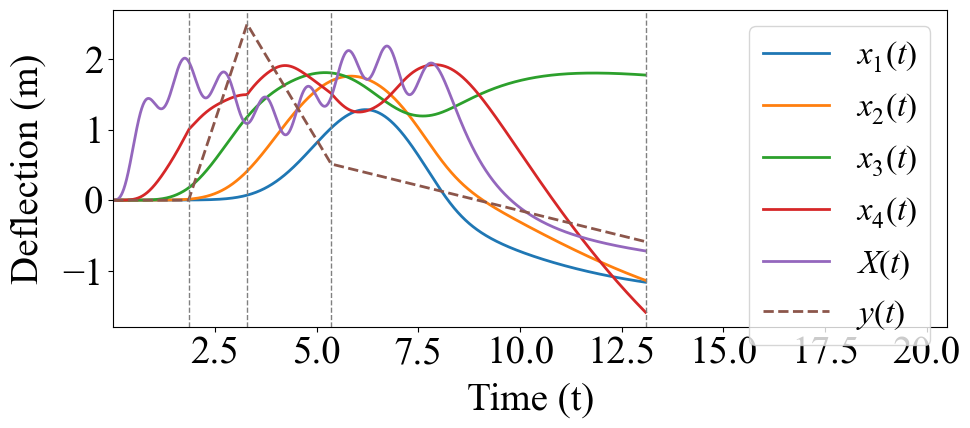

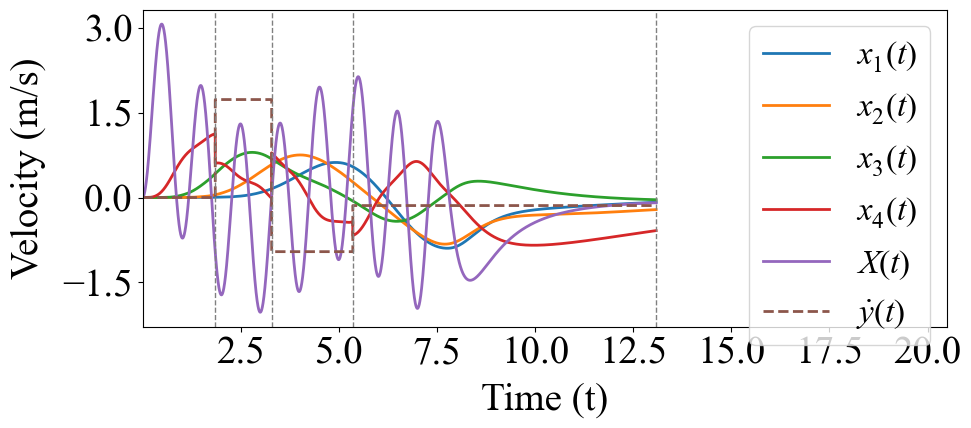

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import matplotlib as mpl

mpl.rcParams['font.family'] = 'Times New Roman'
mpl.rcParams['mathtext.fontset'] = 'custom'
mpl.rcParams['mathtext.rm'] = 'Times New Roman'
mpl.rcParams['mathtext.it'] = 'Times New Roman:italic'
mpl.rcParams['mathtext.bf'] = 'Times New Roman:bold'


impact_time_stamps = np.cumsum(impact_times)

# Font and line settings
fontsize_labels = 28
fontsize_ticks = 28
fontsize_legend = 24
linewidth_plot = 2
linewidth_vline = 1

# --- Figure 1: Deflection vs Time ---
plt.figure(figsize=(10, 4.5))
plt.plot(all_time, all_x[:,0:1], label=r"$x_1(t)$", linewidth=linewidth_plot)
plt.plot(all_time, all_x[:,1:2], label=r"$x_2(t)$", linewidth=linewidth_plot)
plt.plot(all_time, all_x[:,2:3], label=r"$x_3(t)$", linewidth=linewidth_plot)
plt.plot(all_time, all_x[:,3:4], label=r"$x_4(t)$", linewidth=linewidth_plot)
plt.plot(all_time, all_x[:,4:5], label=r"$X(t)$", linewidth=linewidth_plot)
plt.plot(all_time, all_y, label=r"$y(t)$", linestyle='--', linewidth=linewidth_plot)

for t_imp in impact_time_stamps:
    plt.axvline(x=t_imp, color='gray', linestyle='--', linewidth=linewidth_vline)

plt.xlabel("Time (t)", fontsize=fontsize_labels, labelpad=8)
plt.ylabel("Deflection (m)", fontsize=fontsize_labels, labelpad=12)

ax = plt.gca()
ax.xaxis.set_major_locator(MaxNLocator(nbins=10, prune='both'))
ax.yaxis.set_major_locator(MaxNLocator(nbins=5, prune='both'))

ax.tick_params(axis='both', labelsize=fontsize_ticks)

plt.legend(fontsize=fontsize_legend, loc= 'upper right')
plt.tight_layout(pad=1.5)
plt.xlim(0, 20.5)
#plt.ylim(-1.8, 1.8)
plt.savefig("deflection_vs_time.png", format='png', dpi=300)
plt.show()

# --- Figure 2: Velocity vs Time ---
plt.figure(figsize=(10, 4.5))
plt.plot(all_time, all_xt[:,0:1], label=r"$x_1(t)$", linewidth=linewidth_plot)
plt.plot(all_time, all_xt[:,1:2], label=r"$x_2(t)$", linewidth=linewidth_plot)
plt.plot(all_time, all_xt[:,2:3], label=r"$x_3(t)$", linewidth=linewidth_plot)
plt.plot(all_time, all_xt[:,3:4], label=r"$x_4(t)$", linewidth=linewidth_plot)
plt.plot(all_time, all_xt[:,4:5], label=r"$X(t)$", linewidth=linewidth_plot)
plt.plot(all_time, all_yt, label=r"$\dot{y}(t)$", linestyle='--', linewidth=linewidth_plot)

for t_imp in impact_time_stamps:
    plt.axvline(x=t_imp, color='gray', linestyle='--', linewidth=linewidth_vline)

plt.xlabel("Time (t)", fontsize=fontsize_labels, labelpad=8)
plt.ylabel("Velocity (m/s)", fontsize=fontsize_labels, labelpad=12)

ax = plt.gca()
ax.xaxis.set_major_locator(MaxNLocator(nbins=10, prune='both'))
ax.yaxis.set_major_locator(MaxNLocator(nbins=5, prune='both'))

ax.tick_params(axis='both', labelsize=fontsize_ticks)

plt.legend(fontsize=fontsize_legend, loc= 'upper right')
plt.tight_layout(pad=1.5)
plt.xlim(0, 20.5)
#plt.ylim(-1, 1)
plt.savefig("velocity_vs_time.png", format='png', dpi=300)
plt.show()


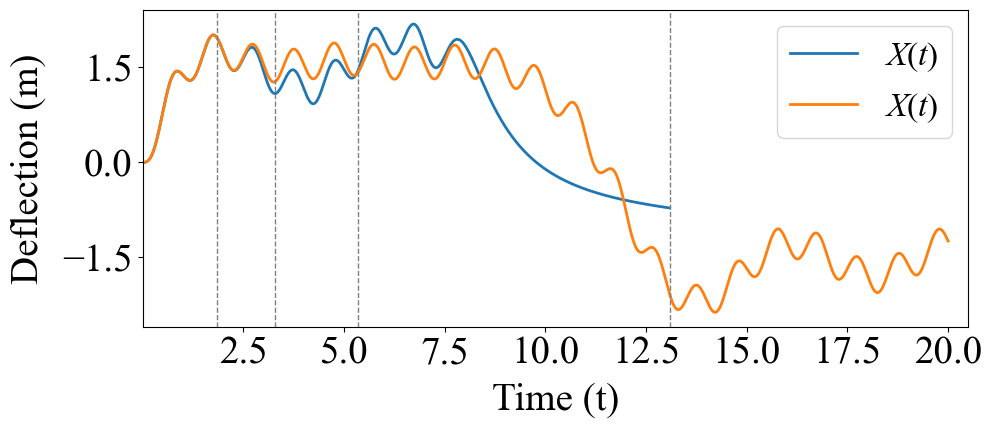

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import matplotlib as mpl

mpl.rcParams['font.family'] = 'Times New Roman'
mpl.rcParams['mathtext.fontset'] = 'custom'
mpl.rcParams['mathtext.rm'] = 'Times New Roman'
mpl.rcParams['mathtext.it'] = 'Times New Roman:italic'
mpl.rcParams['mathtext.bf'] = 'Times New Roman:bold'


impact_time_stamps = np.cumsum(impact_times)

# Font and line settings
fontsize_labels = 28
fontsize_ticks = 28
fontsize_legend = 24
linewidth_plot = 2
linewidth_vline = 1

# --- Figure 1: Deflection vs Time ---
plt.figure(figsize=(10, 4.5))
plt.plot(all_time, all_x[:,4:5], label=r"$X(t)$", linewidth=linewidth_plot)
plt.plot(t_or, np.transpose(u_NM[4:5,:]), label=r"$X(t)$", linewidth=linewidth_plot)

for t_imp in impact_time_stamps:
    plt.axvline(x=t_imp, color='gray', linestyle='--', linewidth=linewidth_vline)

plt.xlabel("Time (t)", fontsize=fontsize_labels, labelpad=8)
plt.ylabel("Deflection (m)", fontsize=fontsize_labels, labelpad=12)

ax = plt.gca()
ax.xaxis.set_major_locator(MaxNLocator(nbins=10, prune='both'))
ax.yaxis.set_major_locator(MaxNLocator(nbins=5, prune='both'))

ax.tick_params(axis='both', labelsize=fontsize_ticks)

plt.legend(fontsize=fontsize_legend, loc= 'upper right')
plt.tight_layout(pad=1.5)
plt.xlim(0, 20.5)
#plt.ylim(-1.8, 1.8)
plt.savefig("deflection_vs_time.png", format='png', dpi=300)
plt.show()

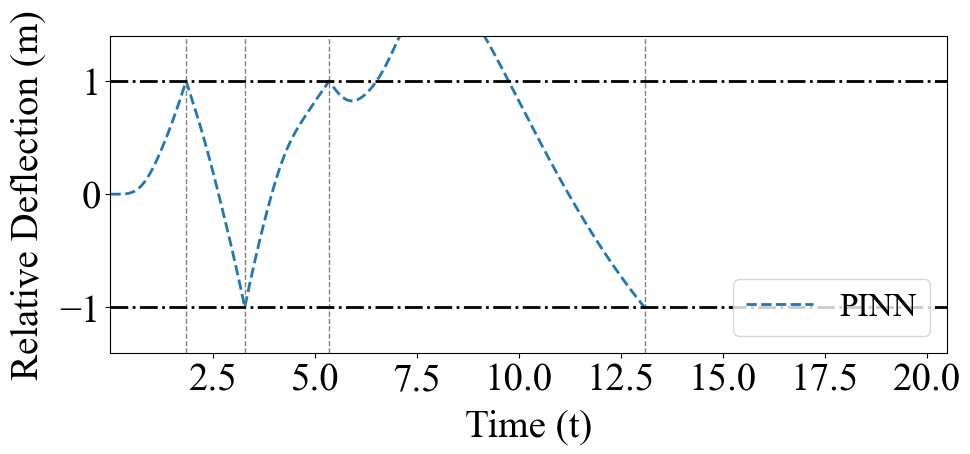

In [23]:
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.ticker import MaxNLocator
import numpy as np

# Set Times New Roman font
mpl.rcParams['font.family'] = 'Times New Roman'
mpl.rcParams['mathtext.fontset'] = 'custom'
mpl.rcParams['mathtext.rm'] = 'Times New Roman'
mpl.rcParams['mathtext.it'] = 'Times New Roman:italic'
mpl.rcParams['mathtext.bf'] = 'Times New Roman:bold'
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

# Font and plot settings
fontsize_labels = 28
fontsize_ticks = 28
fontsize_legend = 24
linewidth_plot = 2
linewidth_vline = 1

# Convert impact time deltas to cumulative timestamps
impact_time_stamps = np.cumsum(impact_times)

# --- Figure 1: Relative Deflection (x - y) ---
plt.figure(figsize=(10, 4.5))
plt.plot(all_time, all_x[:,3:4] - all_y,  label=r"PINN", linestyle='--', linewidth=2)

# Vertical impact lines: gray dashed, thin
for t_imp in impact_time_stamps:
    plt.axvline(x=t_imp, color='gray', linestyle='--', linewidth=1)

# Horizontal reference lines at ±1: dark, thick
plt.axhline(y=1, color='black', linestyle='-.', linewidth=2)
plt.axhline(y=-1, color='black', linestyle='-.', linewidth=2)

plt.xlabel("Time (t)", fontsize=fontsize_labels, labelpad=8)
plt.ylabel("Relative Deflection (m)", fontsize=fontsize_labels, labelpad=10)

ax = plt.gca()
ax.xaxis.set_major_locator(MaxNLocator(nbins=10, prune='both'))
#ax.yaxis.set_major_locator(MaxNLocator(nbins=3, prune='both'))
ax.tick_params(axis='both', labelsize=fontsize_ticks)

plt.legend(fontsize=fontsize_legend, loc= 'lower right')
plt.tight_layout(pad=1.5)
plt.xlim(0, 20.5)
plt.ylim(-1.4, 1.4)
plt.savefig("relative_deflection.png", format='png', dpi=300)
plt.show()

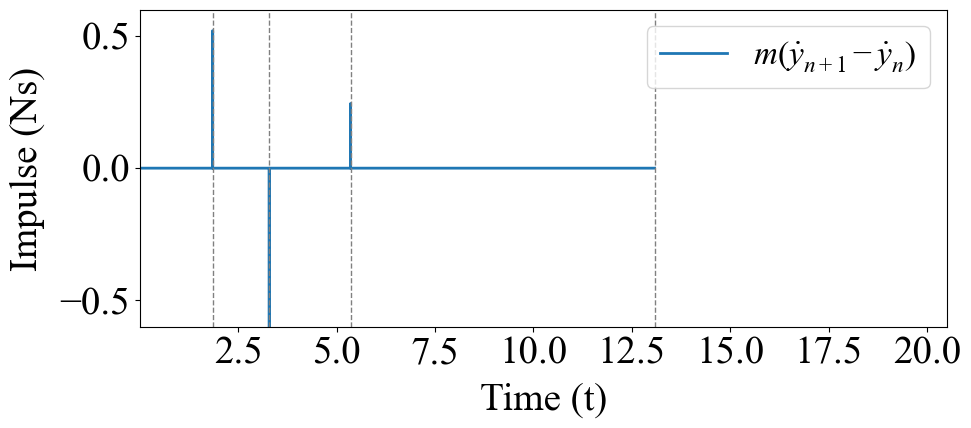

In [24]:
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.ticker import MaxNLocator
import numpy as np

# Set font to Times New Roman
mpl.rcParams['font.family'] = 'Times New Roman'
mpl.rcParams['mathtext.fontset'] = 'custom'
mpl.rcParams['mathtext.rm'] = 'Times New Roman'
mpl.rcParams['mathtext.it'] = 'Times New Roman:italic'
mpl.rcParams['mathtext.bf'] = 'Times New Roman:bold'
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

# Font and line settings
fontsize_labels = 28
fontsize_ticks = 28
fontsize_legend = 24
linewidth_plot = 2
linewidth_vline = 1

# Compute impulse
delta_yt = np.diff(all_yt, axis=0)
time_for_delta_yt = all_time[:-1]
impulse = my4 * delta_yt

# Get symmetric y-limit
max_impulse = np.max(np.abs(impulse))

# Cumulative impact times
impact_time_stamps = np.cumsum(impact_times)

# Plot
plt.figure(figsize=(10, 4.5))
plt.plot(time_for_delta_yt, impulse, label=r"$m(\dot{y}_{n+1} - \dot{y}_n)$", linewidth=linewidth_plot)

# Vertical impact lines
for t_imp in impact_time_stamps:
    plt.axvline(x=t_imp, color='gray', linestyle='--', linewidth=linewidth_vline)

# Symmetric y-axis
plt.ylim(-max_impulse, max_impulse)

plt.xlabel("Time (t)", fontsize=fontsize_labels, labelpad=8)
plt.ylabel("Impulse (Ns)", fontsize=fontsize_labels, labelpad=10)

ax = plt.gca()
ax.xaxis.set_major_locator(MaxNLocator(nbins=10, prune='both'))
#ax.yaxis.set_major_locator(MaxNLocator(nbins=3, prune='both'))
ax.tick_params(axis='both', labelsize=fontsize_ticks)

plt.legend(fontsize=fontsize_legend)
plt.tight_layout(pad=1.5)
plt.xlim(0, 20.5)
plt.ylim(-0.6, 0.6)
plt.savefig("impulse_plot.png", format='png', dpi=300)
plt.show()


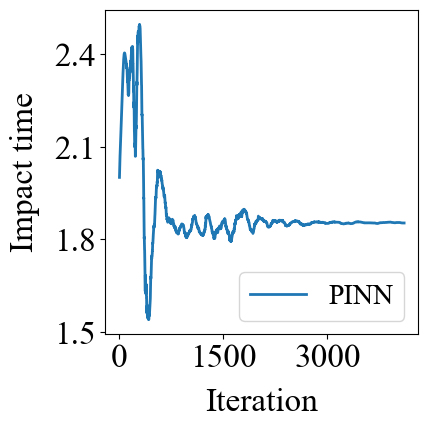

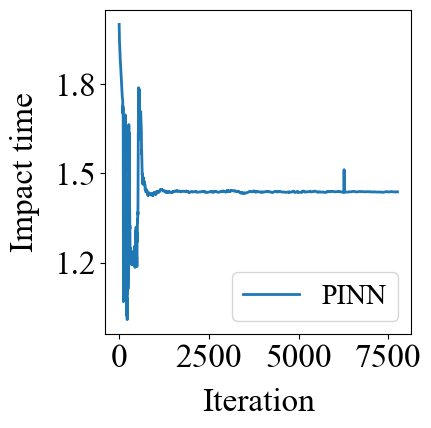

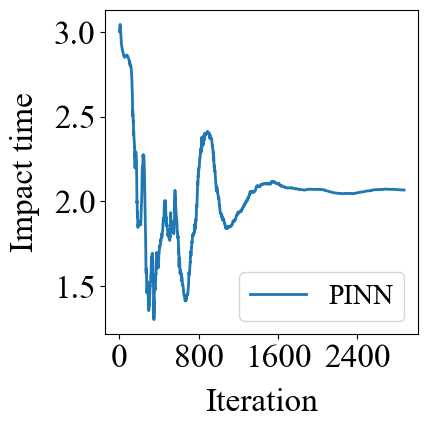

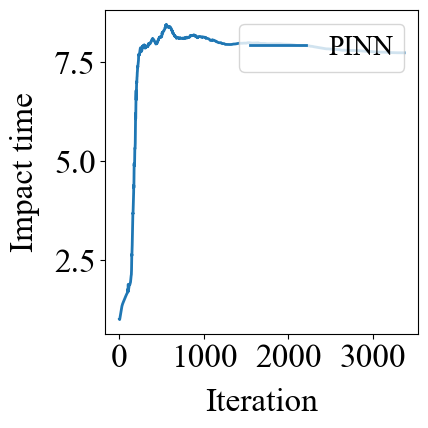

In [25]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import MaxNLocator
import matplotlib as mpl
from matplotlib.ticker import FormatStrFormatter

# Set font to Times New Roman
mpl.rcParams['font.family'] = 'Times New Roman'
mpl.rcParams['mathtext.fontset'] = 'custom'
mpl.rcParams['mathtext.rm'] = 'Times New Roman'
mpl.rcParams['mathtext.it'] = 'Times New Roman:italic'
mpl.rcParams['mathtext.bf'] = 'Times New Roman:bold'
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

# Plot each impact’s convergence with event-based comparison
for i, lambda_log in enumerate(time_log_list):
    plt.figure(figsize=(4.5, 4.5))
    plt.plot(lambda_log, linewidth=2, label=fr"PINN")

    # Add event-based horizontal reference line
    #event_based_time = impact_time_event[i]
    #plt.axhline(y=event_based_time, color='black', linestyle='--', linewidth=2, label="Reference")

    plt.xlabel("Iteration", fontsize=24, labelpad=10)
    plt.ylabel("Impact time", fontsize=24, labelpad=10)

    ax = plt.gca()
    ax.xaxis.set_major_locator(MaxNLocator(nbins=4, prune='both'))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=4, prune='both'))
    #ax.yaxis.set_major_formatter(FuncFormatter(adaptive_formatter))
    ax.tick_params(axis='both', labelsize=24)

    legend_loc = 'upper right' if i in {3, 4, 5} else 'lower right'
    ax.legend(fontsize=20, loc=legend_loc)

    plt.tight_layout(pad=1.5)
    plt.savefig(f'impact_convergence_{i+1}.png', format='png', dpi=300)
    plt.show()


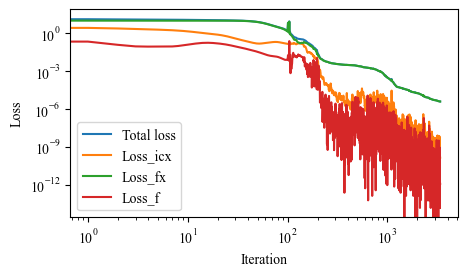

In [26]:
# Restore loss_res and loss_bcs
loss= model.loss_log
loss_icx= model.loss_icx_log
loss_fx= model.loss_fx_log
loss_f= model.loss_f_log

fig, ax = plt.subplots(figsize=(5, 2.7))
ax.loglog(loss, label='Total loss')
ax.loglog(loss_icx, label='Loss_icx')
ax.loglog(loss_fx, label='Loss_fx')
ax.loglog(loss_f, label='Loss_f')
ax.set_xlabel('Iteration')  # Add an x-label to the axes.
ax.set_ylabel('Loss')  # Add a y-label to the axes.
ax.legend()  # Add a legend.